# Darwin: With Dayzer 

In [ ]:
# Portfolio Construction — loop through dates from df (previous cell predictions)
import sys, os, inspect, shutil
sys.path.insert(0, '/var/www/python/Qingcheng/Darwin')
sys.path.append('/var/www/python/Prod/nighthawk/')
import warnings
warnings.filterwarnings('ignore')
import datetime as dt
import pandas as pd
import numpy as np
from nighthawk.util import bigquery_functions, connections, sql_functions
from nighthawk.data.pipeline.var_handler import loadwindgen_vh, wind_vh
from nighthawk.data.pipeline.common_functions import wind
from nighthawk.data.pipeline.var_handler.naturalgas_vh import get_data_and_mapping_for_natural_gas
from google.cloud import bigquery
import utils_darwin.ve_portfolio_constructor_darwin as ve_portfolio_constructor_darwin

sys.path.append('/var/www/python/Qingcheng/Darwin/production/SPP/')
from commonFunctions import get_scale_factor

# --- helper functions ---

def hourly_lwg_cut_darwin(darwin_df, lwg_rampup_interaction_mw_cutoff):
    bid_date = np.unique(darwin_df['dt'])[0]
    total_lwg_df = loadwindgen_vh.get_data_and_mapping_for_total_lwg(
        [636], "SPP",
        start_dt=(pd.to_datetime(bid_date) - pd.to_timedelta('30D')).strftime('%Y-%m-%d'),
        end_dt=(pd.to_datetime(bid_date) + pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
        n_day_pctl_flag=True)[0]
    total_lwg_df = total_lwg_df[total_lwg_df['dt'] == bid_date].reset_index(drop=True)
    if total_lwg_df.shape[0] == 0:
        return darwin_df
    required_cols = ['Perc_30D_spp_loadwindgen_forecast_f', 'Perc_30D_ForwardRamp6_spp_loadwindgen_forecast_f']
    if not all(c in total_lwg_df.columns for c in required_cols):
        return darwin_df
    darwin_df = darwin_df.merge(total_lwg_df[['dt', 'hr'] + required_cols],
                                on=['dt', 'hr'], how='left', suffixes=('', '_lwg'))
    mask = ((darwin_df['Perc_30D_spp_loadwindgen_forecast_f'] >= 0.95) &
            (darwin_df['Perc_30D_ForwardRamp6_spp_loadwindgen_forecast_f'] <= 0.1))
    for hr in darwin_df.loc[mask, 'hr'].unique():
        hr_mask = darwin_df['hr'] == hr
        total_mw = darwin_df.loc[hr_mask, 'bid_mw'].sum()
        if total_mw > lwg_rampup_interaction_mw_cutoff:
            darwin_df.loc[hr_mask, 'bid_mw'] *= (lwg_rampup_interaction_mw_cutoff / total_mw)
    darwin_df.drop(columns=required_cols, inplace=True, errors='ignore')
    return darwin_df

def apply_gas_price_based_price_filter(df, gas_price):
    if gas_price['natural_gas_henry_f'].isna().sum() == 0:
        henry = gas_price['natural_gas_henry_f'].values[0]
        if henry <= 4.5:
            df['bid_price'] = np.where((df['incdec'] == 'Decrement') & (df['bid_price'] >= 150), 150, df['bid_price'])
        if henry >= 4.5:
            df['bid_price'] = np.where((df['incdec'] == 'Increment') & (df['bid_price'] < -50), -50, df['bid_price'])
    df['bid_price'] = np.where((df['incdec'] == 'Decrement') & (df['bid_price'] >= 250), 250, df['bid_price'])
    df['bid_price'] = np.where((df['incdec'] == 'Increment') & (df['bid_price'] <= -100), -100, df['bid_price'])
    return df

def apply_price_filter(df):
    df['bid_price'] = np.where((df['incdec'] == 'Increment') & (df['bid_price'] < -100), -100, df['bid_price'])
    df['bid_price'] = np.where((df['incdec'] == 'Decrement') & (df['bid_price'] > 300), 300, df['bid_price'])
    return df[df['bid_price'] < 2000]

def portfolio_cut(portfolio, bid_date):
    portfolio = apply_price_filter(portfolio)
    gas_price, _ = get_data_and_mapping_for_natural_gas([636], 'SPP', bid_date, bid_date, var_spec=['f'], impute=True)
    gas_price = gas_price[['dt', 'natural_gas_henry_f']].groupby('dt').mean().reset_index()
    if gas_price['natural_gas_henry_f'].isna().sum() == 0:
        if gas_price['natural_gas_henry_f'].values[0] <= 3:
            portfolio = hourly_lwg_cut_darwin(portfolio, 400)
    portfolio = apply_gas_price_based_price_filter(portfolio, gas_price)
    portfolio = portfolio[portfolio['bid_mw'] > 0]
    return portfolio

def _wind_scale_factor(row):
    if row <= 0.05:   return 0.4
    elif row <= 0.3:  return 0.8
    elif row <= 0.9:  return 1
    else:             return 1.25

def scale_by_wind(bid_date, opexchange):
    wind_start_dt = (pd.to_datetime(bid_date) - pd.to_timedelta('120D')).strftime('%Y-%m-%d')
    wind_obj = wind.Wind(opexchange)
    daily_wind_df = wind_obj.get_total_wind(wind_start_dt, bid_date, var_spec=['f'], impute=True)
    col = 'daily_total_wind_forecast_f'
    daily_wind_df = daily_wind_df.groupby(['dt'])['spp_wind_total_forecast_f'].agg(['mean']).reset_index()
    daily_wind_df.columns = ['dt', col]
    daily_wind_df['120DPerc_' + col] = daily_wind_df[col].rolling(120, min_periods=1).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1])
    daily_wind_df = daily_wind_df[daily_wind_df['dt'] == bid_date].reset_index(drop=True)
    if daily_wind_df.shape[0] > 0:
        return _wind_scale_factor(daily_wind_df['120DPerc_' + col].values[0])
    return 1.0

# --- config ---
opexchange = 'SPP'
run_number = 1
file_location_cloudserver = '/var/www/python/Qingcheng/temp_test/'
os.makedirs(file_location_cloudserver + 'return_and_risk', exist_ok=True)
os.makedirs(file_location_cloudserver + 'nodeSelection', exist_ok=True)
conn = connections.get_sql_connection(database='temp')

# --- segments ---
segments_inc = pd.DataFrame({'quantile_DA': ['da_total_q80', 'da_total_q70', 'da_total_q60', 'da_total_q50',
                                              'da_total_q40', 'da_total_q30', 'da_total_q20', 'da_total_q15',
                                              'da_total_q10', 'da_total_q5', 'da_total_q3'],
                              'decSegment': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
                              'incSegment': [11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]})
segments_dec = pd.DataFrame({'quantile_DA': ['da_total_q97', 'da_total_q95', 'da_total_q90', 'da_total_q85',
                                              'da_total_q80', 'da_total_q70', 'da_total_q60', 'da_total_q50',
                                              'da_total_q40', 'da_total_q30', 'da_total_q20'],
                              'decSegment': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
                              'incSegment': [15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5]})
segments = pd.concat([segments_inc.assign(incdec='Increment'), segments_dec.assign(incdec='Decrement')])
segments_clear_prob = pd.DataFrame({
    'segment': list(range(1, 16)),
    'clearProb': [0.97, 0.95, 0.9, 0.85, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.15, 0.1, 0.05, 0.03]})

df = pd.read_csv('/var/www/python/Qingcheng/WFiles/spptest_with_dayzer.csv')
# --- loop through each date in df ---
all_portfolios = []
dates = sorted(df['dt'].unique())
print(f'Running portfolio construction for {len(dates)} dates: {dates}')

try:
    for bid_date in dates:
        print(f'\n--- {bid_date} ---')
        try:
            # 1. Prepare valuation model from df
            df_date = df[df['dt'] == bid_date].copy()
            df_date['node_num'] = df_date['node_num'].astype(int)
            df_date['dt'] = df_date['dt'].astype(str)
            df_date['hr'] = df_date['hr'].astype(int)

            total_col = [c for c in df_date.columns if c.startswith('da_total_') or c.startswith('rt_total_')]
            valuationModel = df_date[df_date['y_list'].isin(['rt_total', 'da_total'])][
                ['dt', 'hr', 'node_num'] + total_col].groupby(['dt', 'hr', 'node_num']).max().reset_index()

            if 'da_congestion_mean' in df_date.columns:
                congestionModel = df_date[df_date['y_list'].isin(['rt_congestion', 'da_congestion'])][
                    ['dt', 'hr', 'node_num', 'da_congestion_mean', 'rt_congestion_mean']].groupby(
                    ['dt', 'hr', 'node_num']).max().reset_index()
                valuationModel = pd.merge(valuationModel, congestionModel, on=['dt', 'hr', 'node_num'], how='left')

            # 2. Node selection
            nodeSelection = pd.read_sql(
                f"SELECT * FROM Fourier_{opexchange}.nodeSelection WHERE dt = '{bid_date}' AND source = 'PCA'", conn)
            nodeSelection['dt'] = nodeSelection['dt'].astype(str)
            nodeSelection['node_num'] = nodeSelection['node_num'].astype(int)
            nodeSelection_label = 'nodeLookback120_lmpLookback7_curieCorrCutF_dfMeanoff_pcNode2_cutoff90'
            nodeSelection['nodeSelection'] = nodeSelection_label
            nodeSelection.to_csv(file_location_cloudserver + 'nodeSelection/' + bid_date + '.csv', index=False)

            # 3. Get op_rate and ref price
            ve_port = ve_portfolio_constructor_darwin.VEPortfolioConstructorDarwin(opexchange)
            valuationModel = ve_port.get_oprate_lmp_price_and_ref_value(valuationModel)
            for col in ['op_rate_inc_a', 'op_rate_dec_a', 'op_rate_inc_f', 'op_rate_dec_f', 'bid_ref_price', 'offer_ref_price']:
                if col in valuationModel.columns:
                    valuationModel[col].fillna(value=valuationModel[col].mean(), inplace=True)

            # 4. Calculate return and risk
            ve_port.calculate_cumulative_return_and_risk_for_one_day(
                valuationModel, save_cloudserver_location=file_location_cloudserver + 'return_and_risk/',
                prediction='total', segments=segments, date=bid_date)

            # 5. Wind / LWG for constraints
            total_wind_df = wind_vh.get_data_and_mapping_for_total_market_wind(
                node_list=[636], opexchange='SPP',
                start_dt=(pd.to_datetime(bid_date) - pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
                end_dt=(pd.to_datetime(bid_date) + pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
                var_spec=['f'], impute=True, ramp_flag=True, ramp_periods=[2])[0]
            total_lwg_df = loadwindgen_vh.get_data_and_mapping_for_total_lwg(
                [636], "SPP",
                start_dt=(pd.to_datetime(bid_date) - pd.to_timedelta('35D')).strftime('%Y-%m-%d'),
                end_dt=(pd.to_datetime(bid_date) + pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
                n_day_pctl_flag=True)[0]

            constraints_option = ['option24', {
                'max_mw_per_segment': 5, 'totalRiskAllowed': 10000, 'total_mw_limit': 20000,
                'nodal_mw_limit': 700, 'nodal_hrly_mw_limit': 60, 'nodal_hrly_incdec_mw_limit': 40,
                'totalCollateralAllowed': 700000, 'inc_upper_perc_limit': 0.7, 'dec_upper_perc_limit': 0.7,
                'hrly_inc_mw_limit': 450,
                'hrly_inc_upper_perc_limit_extreme_physical_condition': {
                    'BackwardRampNoSlope2_spp_wind_total_forecast_f': -3000,
                    'hrly_inc_upper_perc_limit': 0.1, 'physical_var_df': total_wind_df},
            }]
            if 'Perc_30D_spp_loadwindgen_forecast_f' in total_lwg_df.columns:
                constraints_option[1]['hrly_dec_upper_perc_limit_extreme_physical_condition'] = {
                    'Perc_30D_spp_loadwindgen_forecast_f': 0.02, 'hrly_dec_upper_perc_limit': 0.2,
                    'physical_var_df': total_lwg_df}

            # 6. Portfolio construction
            para = {'maxDecPrice': 250, 'minIncPrice': -100, 'PowerROC': 1,
                    'minExpectedProfit': 0.7, 'maximumROR': 500, 'minimumROR': 250, 'maximumROC': 100,
                    'MinExpectedReturnOnCollateral': 0, 'maxSegmentNum': 8,
                    'objectiveFunction': 'expectedProfit',
                    'constraints_option': constraints_option, 'PortionOfFullRisk': 1,
                    'segments_clear_prob': segments_clear_prob,
                    'data_location': file_location_cloudserver,
                    'nodeSelection_label': nodeSelection_label,
                    'valuationModel_label': '', 'condition_label': 2, 'cumulativeRisk_ceil': -0.1}
            portfolio = ve_port.get_daily_terence_portfolio(bid_date, **para)

            # 7. Cut and scale
            portfolio = portfolio[portfolio['bid_mw'] > 0]
            portfolio = portfolio_cut(portfolio, bid_date)
            wind_sf = scale_by_wind(bid_date, opexchange)
            scale_f = get_scale_factor(opexchange)
            portfolio['bid_mw'] = portfolio['bid_mw'] * scale_f * wind_sf
            portfolio['run_number'] = run_number

            print(f'  {len(portfolio)} bids, {round(portfolio["bid_mw"].sum())} total MW')
            all_portfolios.append(portfolio)

        except Exception as e:
            print(f'  [SKIP] {bid_date}: {e}')
            continue



finally:
    shutil.rmtree(file_location_cloudserver, ignore_errors=True)
    print(f'Cleaned up {file_location_cloudserver}')

# --- concat and save ---
if all_portfolios:
    final_portfolio = pd.concat(all_portfolios, ignore_index=True)
    save_path = '/var/www/python/Qingcheng/WFiles/darwin_port_with_dayzer.csv'
    final_portfolio.to_csv(save_path, index=False)
    print(f'\nSaved {final_portfolio.shape} to {save_path}')
else:
    print('No portfolios generated.')

Running portfolio construction for 80 dates: ['2026-01-10', '2026-01-11', '2026-01-12', '2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16', '2026-01-17', '2026-01-18', '2026-01-19', '2026-01-20', '2026-01-21', '2026-01-22', '2026-01-23', '2026-01-24', '2026-01-25', '2026-01-26', '2026-01-27', '2026-01-28', '2026-01-29', '2026-01-30', '2026-01-31', '2026-02-01', '2026-02-02', '2026-02-03', '2026-02-04', '2026-02-05', '2026-02-06', '2026-02-07', '2026-02-08', '2026-02-09', '2026-02-10', '2026-02-11', '2026-02-12', '2026-02-13', '2026-02-14', '2026-02-15', '2026-02-16', '2026-02-17', '2026-02-18', '2026-02-19', '2026-02-20', '2026-02-21', '2026-02-22', '2026-02-23', '2026-02-24', '2026-02-25', '2026-02-26', '2026-02-27', '2026-02-28', '2026-03-01', '2026-03-02', '2026-03-03', '2026-03-04', '2026-03-05', '2026-03-06', '2026-03-07', '2026-03-08', '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12', '2026-03-13', '2026-03-14', '2026-03-15', '2026-03-16', '2026-03-17', '2026-03-18', '2

sudo: a terminal is required to read the password; either use the -S option to read from standard input or configure an askpass helper
sudo: a password is required


  1676 bids, 7539 total MW

--- 2026-01-11 ---
Getting OpRate info
Getting LMP info
Getting Reference Value info


sudo: a terminal is required to read the password; either use the -S option to read from standard input or configure an askpass helper
sudo: a password is required


  1612 bids, 7242 total MW

--- 2026-01-12 ---
Getting OpRate info
Getting LMP info
Getting Reference Value info


...

  1795 bids, 8049 total MW

--- 2026-03-29 ---
Getting OpRate info
Getting LMP info
Getting Reference Value info


sudo: a terminal is required to read the password; either use the -S option to read from standard input or configure an askpass helper
sudo: a password is required


  1850 bids, 8311 total MW

--- 2026-03-30 ---
Getting OpRate info
Getting LMP info
Getting Reference Value info


sudo: a terminal is required to read the password; either use the -S option to read from standard input or configure an askpass helper
sudo: a password is required


  1714 bids, 7707 total MW
Cleaned up /var/www/python/Qingcheng/temp_test/

Saved (129642, 35) to /var/www/python/Qingcheng/WFiles/darwin_portfolio.csv


# Darwin: without Dayzer

In [1]:
# Portfolio Construction — loop through dates from df (previous cell predictions)
import sys, os, inspect, shutil
sys.path.insert(0, '/var/www/python/Qingcheng/Darwin')
sys.path.append('/var/www/python/Prod/nighthawk/')
import warnings
warnings.filterwarnings('ignore')
import datetime as dt
import pandas as pd
import numpy as np
from nighthawk.util import bigquery_functions, connections, sql_functions
from nighthawk.data.pipeline.var_handler import loadwindgen_vh, wind_vh
from nighthawk.data.pipeline.common_functions import wind
from nighthawk.data.pipeline.var_handler.naturalgas_vh import get_data_and_mapping_for_natural_gas
from google.cloud import bigquery
import utils_darwin.ve_portfolio_constructor_darwin as ve_portfolio_constructor_darwin

sys.path.append('/var/www/python/Qingcheng/Darwin/production/SPP/')
from commonFunctions import get_scale_factor

# --- helper functions ---

def hourly_lwg_cut_darwin(darwin_df, lwg_rampup_interaction_mw_cutoff):
    bid_date = np.unique(darwin_df['dt'])[0]
    total_lwg_df = loadwindgen_vh.get_data_and_mapping_for_total_lwg(
        [636], "SPP",
        start_dt=(pd.to_datetime(bid_date) - pd.to_timedelta('30D')).strftime('%Y-%m-%d'),
        end_dt=(pd.to_datetime(bid_date) + pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
        n_day_pctl_flag=True)[0]
    total_lwg_df = total_lwg_df[total_lwg_df['dt'] == bid_date].reset_index(drop=True)
    if total_lwg_df.shape[0] == 0:
        return darwin_df
    required_cols = ['Perc_30D_spp_loadwindgen_forecast_f', 'Perc_30D_ForwardRamp6_spp_loadwindgen_forecast_f']
    if not all(c in total_lwg_df.columns for c in required_cols):
        return darwin_df
    darwin_df = darwin_df.merge(total_lwg_df[['dt', 'hr'] + required_cols],
                                on=['dt', 'hr'], how='left', suffixes=('', '_lwg'))
    mask = ((darwin_df['Perc_30D_spp_loadwindgen_forecast_f'] >= 0.95) &
            (darwin_df['Perc_30D_ForwardRamp6_spp_loadwindgen_forecast_f'] <= 0.1))
    for hr in darwin_df.loc[mask, 'hr'].unique():
        hr_mask = darwin_df['hr'] == hr
        total_mw = darwin_df.loc[hr_mask, 'bid_mw'].sum()
        if total_mw > lwg_rampup_interaction_mw_cutoff:
            darwin_df.loc[hr_mask, 'bid_mw'] *= (lwg_rampup_interaction_mw_cutoff / total_mw)
    darwin_df.drop(columns=required_cols, inplace=True, errors='ignore')
    return darwin_df

def apply_gas_price_based_price_filter(df, gas_price):
    if gas_price['natural_gas_henry_f'].isna().sum() == 0:
        henry = gas_price['natural_gas_henry_f'].values[0]
        if henry <= 4.5:
            df['bid_price'] = np.where((df['incdec'] == 'Decrement') & (df['bid_price'] >= 150), 150, df['bid_price'])
        if henry >= 4.5:
            df['bid_price'] = np.where((df['incdec'] == 'Increment') & (df['bid_price'] < -50), -50, df['bid_price'])
    df['bid_price'] = np.where((df['incdec'] == 'Decrement') & (df['bid_price'] >= 250), 250, df['bid_price'])
    df['bid_price'] = np.where((df['incdec'] == 'Increment') & (df['bid_price'] <= -100), -100, df['bid_price'])
    return df

def apply_price_filter(df):
    df['bid_price'] = np.where((df['incdec'] == 'Increment') & (df['bid_price'] < -100), -100, df['bid_price'])
    df['bid_price'] = np.where((df['incdec'] == 'Decrement') & (df['bid_price'] > 300), 300, df['bid_price'])
    return df[df['bid_price'] < 2000]

def portfolio_cut(portfolio, bid_date):
    portfolio = apply_price_filter(portfolio)
    gas_price, _ = get_data_and_mapping_for_natural_gas([636], 'SPP', bid_date, bid_date, var_spec=['f'], impute=True)
    gas_price = gas_price[['dt', 'natural_gas_henry_f']].groupby('dt').mean().reset_index()
    if gas_price['natural_gas_henry_f'].isna().sum() == 0:
        if gas_price['natural_gas_henry_f'].values[0] <= 3:
            portfolio = hourly_lwg_cut_darwin(portfolio, 400)
    portfolio = apply_gas_price_based_price_filter(portfolio, gas_price)
    portfolio = portfolio[portfolio['bid_mw'] > 0]
    return portfolio

def _wind_scale_factor(row):
    if row <= 0.05:   return 0.4
    elif row <= 0.3:  return 0.8
    elif row <= 0.9:  return 1
    else:             return 1.25

def scale_by_wind(bid_date, opexchange):
    wind_start_dt = (pd.to_datetime(bid_date) - pd.to_timedelta('120D')).strftime('%Y-%m-%d')
    wind_obj = wind.Wind(opexchange)
    daily_wind_df = wind_obj.get_total_wind(wind_start_dt, bid_date, var_spec=['f'], impute=True)
    col = 'daily_total_wind_forecast_f'
    daily_wind_df = daily_wind_df.groupby(['dt'])['spp_wind_total_forecast_f'].agg(['mean']).reset_index()
    daily_wind_df.columns = ['dt', col]
    daily_wind_df['120DPerc_' + col] = daily_wind_df[col].rolling(120, min_periods=1).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1])
    daily_wind_df = daily_wind_df[daily_wind_df['dt'] == bid_date].reset_index(drop=True)
    if daily_wind_df.shape[0] > 0:
        return _wind_scale_factor(daily_wind_df['120DPerc_' + col].values[0])
    return 1.0

# --- config ---
opexchange = 'SPP'
run_number = 1
file_location_cloudserver = '/var/www/python/Qingcheng/temp_test/'
os.makedirs(file_location_cloudserver + 'return_and_risk', exist_ok=True)
os.makedirs(file_location_cloudserver + 'nodeSelection', exist_ok=True)
conn = connections.get_sql_connection(database='temp')

# --- segments ---
segments_inc = pd.DataFrame({'quantile_DA': ['da_total_q80', 'da_total_q70', 'da_total_q60', 'da_total_q50',
                                              'da_total_q40', 'da_total_q30', 'da_total_q20', 'da_total_q15',
                                              'da_total_q10', 'da_total_q5', 'da_total_q3'],
                              'decSegment': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
                              'incSegment': [11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]})
segments_dec = pd.DataFrame({'quantile_DA': ['da_total_q97', 'da_total_q95', 'da_total_q90', 'da_total_q85',
                                              'da_total_q80', 'da_total_q70', 'da_total_q60', 'da_total_q50',
                                              'da_total_q40', 'da_total_q30', 'da_total_q20'],
                              'decSegment': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
                              'incSegment': [15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5]})
segments = pd.concat([segments_inc.assign(incdec='Increment'), segments_dec.assign(incdec='Decrement')])
segments_clear_prob = pd.DataFrame({
    'segment': list(range(1, 16)),
    'clearProb': [0.97, 0.95, 0.9, 0.85, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.15, 0.1, 0.05, 0.03]})

df = pd.read_csv('/var/www/python/Qingcheng/WFiles/spptest_without_dayzer.csv')
# --- loop through each date in df ---
all_portfolios = []
dates = sorted(df['dt'].unique())
print(f'Running portfolio construction for {len(dates)} dates: {dates}')

try:
    for bid_date in dates:
        print(f'\n--- {bid_date} ---')
        try:
            # 1. Prepare valuation model from df
            df_date = df[df['dt'] == bid_date].copy()
            df_date['node_num'] = df_date['node_num'].astype(int)
            df_date['dt'] = df_date['dt'].astype(str)
            df_date['hr'] = df_date['hr'].astype(int)

            total_col = [c for c in df_date.columns if c.startswith('da_total_') or c.startswith('rt_total_')]
            valuationModel = df_date[df_date['y_list'].isin(['rt_total', 'da_total'])][
                ['dt', 'hr', 'node_num'] + total_col].groupby(['dt', 'hr', 'node_num']).max().reset_index()

            if 'da_congestion_mean' in df_date.columns:
                congestionModel = df_date[df_date['y_list'].isin(['rt_congestion', 'da_congestion'])][
                    ['dt', 'hr', 'node_num', 'da_congestion_mean', 'rt_congestion_mean']].groupby(
                    ['dt', 'hr', 'node_num']).max().reset_index()
                valuationModel = pd.merge(valuationModel, congestionModel, on=['dt', 'hr', 'node_num'], how='left')

            # 2. Node selection
            nodeSelection = pd.read_sql(
                f"SELECT * FROM Fourier_{opexchange}.nodeSelection WHERE dt = '{bid_date}' AND source = 'PCA'", conn)
            nodeSelection['dt'] = nodeSelection['dt'].astype(str)
            nodeSelection['node_num'] = nodeSelection['node_num'].astype(int)
            nodeSelection_label = 'nodeLookback120_lmpLookback7_curieCorrCutF_dfMeanoff_pcNode2_cutoff90'
            nodeSelection['nodeSelection'] = nodeSelection_label
            nodeSelection.to_csv(file_location_cloudserver + 'nodeSelection/' + bid_date + '.csv', index=False)

            # 3. Get op_rate and ref price
            ve_port = ve_portfolio_constructor_darwin.VEPortfolioConstructorDarwin(opexchange)
            valuationModel = ve_port.get_oprate_lmp_price_and_ref_value(valuationModel)
            for col in ['op_rate_inc_a', 'op_rate_dec_a', 'op_rate_inc_f', 'op_rate_dec_f', 'bid_ref_price', 'offer_ref_price']:
                if col in valuationModel.columns:
                    valuationModel[col].fillna(value=valuationModel[col].mean(), inplace=True)

            # 4. Calculate return and risk
            ve_port.calculate_cumulative_return_and_risk_for_one_day(
                valuationModel, save_cloudserver_location=file_location_cloudserver + 'return_and_risk/',
                prediction='total', segments=segments, date=bid_date)

            # 5. Wind / LWG for constraints
            total_wind_df = wind_vh.get_data_and_mapping_for_total_market_wind(
                node_list=[636], opexchange='SPP',
                start_dt=(pd.to_datetime(bid_date) - pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
                end_dt=(pd.to_datetime(bid_date) + pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
                var_spec=['f'], impute=True, ramp_flag=True, ramp_periods=[2])[0]
            total_lwg_df = loadwindgen_vh.get_data_and_mapping_for_total_lwg(
                [636], "SPP",
                start_dt=(pd.to_datetime(bid_date) - pd.to_timedelta('35D')).strftime('%Y-%m-%d'),
                end_dt=(pd.to_datetime(bid_date) + pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
                n_day_pctl_flag=True)[0]

            constraints_option = ['option24', {
                'max_mw_per_segment': 5, 'totalRiskAllowed': 10000, 'total_mw_limit': 20000,
                'nodal_mw_limit': 700, 'nodal_hrly_mw_limit': 60, 'nodal_hrly_incdec_mw_limit': 40,
                'totalCollateralAllowed': 700000, 'inc_upper_perc_limit': 0.7, 'dec_upper_perc_limit': 0.7,
                'hrly_inc_mw_limit': 450,
                'hrly_inc_upper_perc_limit_extreme_physical_condition': {
                    'BackwardRampNoSlope2_spp_wind_total_forecast_f': -3000,
                    'hrly_inc_upper_perc_limit': 0.1, 'physical_var_df': total_wind_df},
            }]
            if 'Perc_30D_spp_loadwindgen_forecast_f' in total_lwg_df.columns:
                constraints_option[1]['hrly_dec_upper_perc_limit_extreme_physical_condition'] = {
                    'Perc_30D_spp_loadwindgen_forecast_f': 0.02, 'hrly_dec_upper_perc_limit': 0.2,
                    'physical_var_df': total_lwg_df}

            # 6. Portfolio construction
            para = {'maxDecPrice': 250, 'minIncPrice': -100, 'PowerROC': 1,
                    'minExpectedProfit': 0.7, 'maximumROR': 500, 'minimumROR': 250, 'maximumROC': 100,
                    'MinExpectedReturnOnCollateral': 0, 'maxSegmentNum': 8,
                    'objectiveFunction': 'expectedProfit',
                    'constraints_option': constraints_option, 'PortionOfFullRisk': 1,
                    'segments_clear_prob': segments_clear_prob,
                    'data_location': file_location_cloudserver,
                    'nodeSelection_label': nodeSelection_label,
                    'valuationModel_label': '', 'condition_label': 2, 'cumulativeRisk_ceil': -0.1}
            portfolio = ve_port.get_daily_terence_portfolio(bid_date, **para)

            # 7. Cut and scale
            portfolio = portfolio[portfolio['bid_mw'] > 0]
            portfolio = portfolio_cut(portfolio, bid_date)
            wind_sf = scale_by_wind(bid_date, opexchange)
            scale_f = get_scale_factor(opexchange)
            portfolio['bid_mw'] = portfolio['bid_mw'] * scale_f * wind_sf
            portfolio['run_number'] = run_number

            print(f'  {len(portfolio)} bids, {round(portfolio["bid_mw"].sum())} total MW')
            all_portfolios.append(portfolio)

        except Exception as e:
            print(f'  [SKIP] {bid_date}: {e}')
            continue

finally:
    shutil.rmtree(file_location_cloudserver, ignore_errors=True)
    print(f'Cleaned up {file_location_cloudserver}')

# --- concat and save ---
if all_portfolios:
    final_portfolio = pd.concat(all_portfolios, ignore_index=True)
    save_path = '/var/www/python/Qingcheng/WFiles/darwin_port_wt_dayzer.csv'
    final_portfolio.to_csv(save_path, index=False)
    print(f'\nSaved {final_portfolio.shape} to {save_path}')
else:
    print('No portfolios generated.')

Running portfolio construction for 80 dates: ['2026-01-10', '2026-01-11', '2026-01-12', '2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16', '2026-01-17', '2026-01-18', '2026-01-19', '2026-01-20', '2026-01-21', '2026-01-22', '2026-01-23', '2026-01-24', '2026-01-25', '2026-01-26', '2026-01-27', '2026-01-28', '2026-01-29', '2026-01-30', '2026-01-31', '2026-02-01', '2026-02-02', '2026-02-03', '2026-02-04', '2026-02-05', '2026-02-06', '2026-02-07', '2026-02-08', '2026-02-09', '2026-02-10', '2026-02-11', '2026-02-12', '2026-02-13', '2026-02-14', '2026-02-15', '2026-02-16', '2026-02-17', '2026-02-18', '2026-02-19', '2026-02-20', '2026-02-21', '2026-02-22', '2026-02-23', '2026-02-24', '2026-02-25', '2026-02-26', '2026-02-27', '2026-02-28', '2026-03-01', '2026-03-02', '2026-03-03', '2026-03-04', '2026-03-05', '2026-03-06', '2026-03-07', '2026-03-08', '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12', '2026-03-13', '2026-03-14', '2026-03-15', '2026-03-16', '2026-03-17', '2026-03-18', '2

sudo: a terminal is required to read the password; either use the -S option to read from standard input or configure an askpass helper
sudo: a password is required


  1714 bids, 7708 total MW

--- 2026-01-11 ---
Getting OpRate info
Getting LMP info
Getting Reference Value info


sudo: a terminal is required to read the password; either use the -S option to read from standard input or configure an askpass helper
sudo: a password is required


  1652 bids, 7385 total MW

--- 2026-01-12 ---
Getting OpRate info
Getting LMP info
Getting Reference Value info


...

  1846 bids, 8302 total MW

--- 2026-03-29 ---
Getting OpRate info
Getting LMP info
Getting Reference Value info


sudo: a terminal is required to read the password; either use the -S option to read from standard input or configure an askpass helper
sudo: a password is required


  1874 bids, 8420 total MW

--- 2026-03-30 ---
Getting OpRate info
Getting LMP info
Getting Reference Value info


sudo: a terminal is required to read the password; either use the -S option to read from standard input or configure an askpass helper
sudo: a password is required


  1791 bids, 8051 total MW
Cleaned up /var/www/python/Qingcheng/temp_test/

Saved (132470, 35) to /var/www/python/Qingcheng/WFiles/darwin_port_wt_dayzer.csv


# Convert bids_table to pnl 

In [8]:
import sys
sys.path.append("/var/www/python/Prod/nighthawk/")
from nighthawk.data.product.ve import DailyBidsManager
from nighthawk.data.network.node import Node
import numpy as np 

def simulate_total_ftp(table):

    MARKET_CONFIG = {
    'SPP': {
        'load_table': 'spp_physical.spp_latest_load_forecast',
        'wind_table': 'spp_physical.spp_latest_wind_forecast',
        'inc_op_rate': 2.0,
        'dec_op_rate': 0.1
    },
    'PJM': {
        'load_table': '',
        'wind_table': '',
        'inc_op_rate': 0.0,
        'dec_op_rate': 0.0
    },
    'MISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'ERCOT': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'NYISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
}
    
    m_cfg = MARKET_CONFIG['SPP']
    df_bids = table

    # 3. Prices
    node_list = df_bids['node_num'].unique().tolist()

    node_obj = Node(node_nums=node_list, market='SPP')
    date_start = table.dt.min()
    date_end = table.dt.max()
    print(date_start,date_end)

    df_prices = node_obj.get_price(
        start_dt=date_start,
        end_dt=date_end,
        component=['LMP'],
        type=['DA', 'RT'],
        granularity='hourly'
    )

    if not df_prices.empty:
        df_prices.rename(columns={'da_total': 'dalmp', 'rt_total': 'rtlmp'}, inplace=True)
        df_prices['hr'] = df_prices['hr'].astype(int)
        df_prices['node_num'] = df_prices['node_num'].astype(int)
        df_sim = pd.merge(df_bids, df_prices, left_on=['dt', 'hr', 'node_num'],
                            right_on=['dt', 'hr', 'node_num'], how='left')
    else:
        df_sim['dalmp'] = np.nan
        df_sim['rtlmp'] = np.nan

    # 4. Calculations (Preserved as per instruction)
    inc_op_rate = df_sim['op_rate_inc_a'].mean()
    dec_op_rate = df_sim['op_rate_dec_a'].mean()

    conditions_clear = [
        (df_sim['incdec'] == 'Decrement') & (df_sim['bid_price'] >= df_sim['dalmp']),
        (df_sim['incdec'] == 'Increment') & (df_sim['bid_price'] <= df_sim['dalmp'])
    ]
    df_sim['is_cleared'] = np.select(conditions_clear, [True, True], default=False)
    df_sim.loc[df_sim['dalmp'].isna(), 'is_cleared'] = False
    df_sim['clear_mw'] = np.where(df_sim['is_cleared'], df_sim['bid_mw'], 0.0)

    # DA & RT Cash
    df_sim['total_da_val'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['dalmp'], df_sim['clear_mw'] * df_sim['dalmp'])
    df_sim['total_da_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_val'])

    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rtlmp'], -1 * df_sim['clear_mw'] * df_sim['rtlmp'])
    df_sim['total_rt_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)

    # RSG
    rsg_cost = np.where(df_sim['incdec'] == 'Increment', df_sim['clear_mw'] * inc_op_rate, df_sim['clear_mw'] * dec_op_rate)
    df_sim['op_rate_val'] = np.where(df_sim['rtlmp'].isna(), 0, -1 * rsg_cost)

    # Totals
    df_sim['gross_pnl'] = df_sim['total_da_elapsed'] + df_sim['total_rt_elapsed']
    df_sim['net_pnl'] = df_sim['gross_pnl'] + df_sim['op_rate_val']
    df_sim.fillna(0, inplace=True)

    # 5. Aggregation & Data Return

    agg_dict = {
        'bid_mw': 'sum', 'clear_mw': 'sum',
        'total_da_val': 'sum', 'total_da_elapsed': 'sum', 'total_rt_elapsed': 'sum', 'op_rate_val': 'sum',
        'gross_pnl': 'sum', 'net_pnl': 'sum'
    }
    renamer = {
        'bid_mw': 'BidMW', 'clear_mw': 'ClearMW',
        'total_da_val': 'TotalDA$', 'total_da_elapsed': 'TotalDAElapsed$',
        'total_rt_elapsed': 'TotalRTElapsed$', 'op_rate_val': 'OpRate$',
        'gross_pnl': 'Gross$', 'net_pnl': 'Net$'
    }

    # A. Overall Summary
    summ_data = df_sim.agg(agg_dict).to_frame().T.rename(columns=renamer).to_dict('records')
    return df_sim

In [9]:
dayzer_table = pd.read_csv('/var/www/python/Qingcheng/WFiles/darwin_port_with_dayzer.csv')
dayzer_re = simulate_total_ftp(dayzer_table)
dayzer_wt_table = pd.read_csv('/var/www/python/Qingcheng/WFiles/darwin_port_wt_dayzer.csv')
dayzer_wt_re = simulate_total_ftp(dayzer_wt_table)


2026-01-10 2026-03-30
2026-01-10 2026-03-30


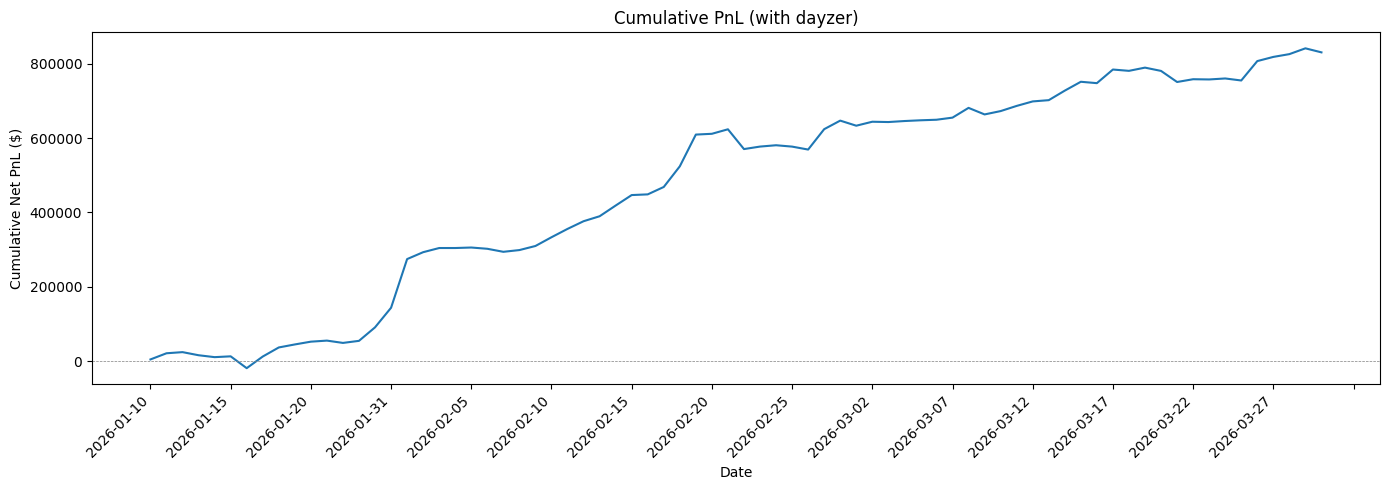

Total PnL:          $830,348.87
Max Daily Loss:     $-53,210.34
Profit-to-Loss:     4.73
Profit Days Total:  $1,053,177.33
Loss Days Total:    $-222,828.46
Win Rate:           74.3%


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# go no go 
date_list = pd.date_range(start='2026-01-23', end='2026-01-28').strftime('%Y-%m-%d').tolist()
dayzer_re = dayzer_re[~dayzer_re['dt'].isin(date_list)]

# Daily PnL
daily_pnl = dayzer_re.groupby('dt')['net_pnl'].sum().reset_index()
daily_pnl.columns = ['dt', 'daily_pnl']
daily_pnl['cumulative_pnl'] = daily_pnl['daily_pnl'].cumsum()

# Cumulative PnL graph
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_pnl['dt'], daily_pnl['cumulative_pnl'], linewidth=1.5)
ax.set_title('Cumulative PnL (with dayzer)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Net PnL ($)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
ax.xaxis.set_major_locator(plt.MaxNLocator(20))
plt.tight_layout()
plt.show()

# Summary stats
total_pnl = daily_pnl['daily_pnl'].sum()
profit_days = daily_pnl[daily_pnl['daily_pnl'] > 0]['daily_pnl'].sum()
loss_days = daily_pnl[daily_pnl['daily_pnl'] < 0]['daily_pnl'].sum()
max_loss = daily_pnl['daily_pnl'].min()
profit_to_loss = abs(profit_days / loss_days) if loss_days != 0 else float('inf')

print(f'Total PnL:          ${total_pnl:,.2f}')
print(f'Max Daily Loss:     ${max_loss:,.2f}')
print(f'Profit-to-Loss:     {profit_to_loss:.2f}')
print(f'Profit Days Total:  ${profit_days:,.2f}')
print(f'Loss Days Total:    ${loss_days:,.2f}')
print(f'Win Rate:           {(daily_pnl["daily_pnl"] > 0).mean():.1%}')

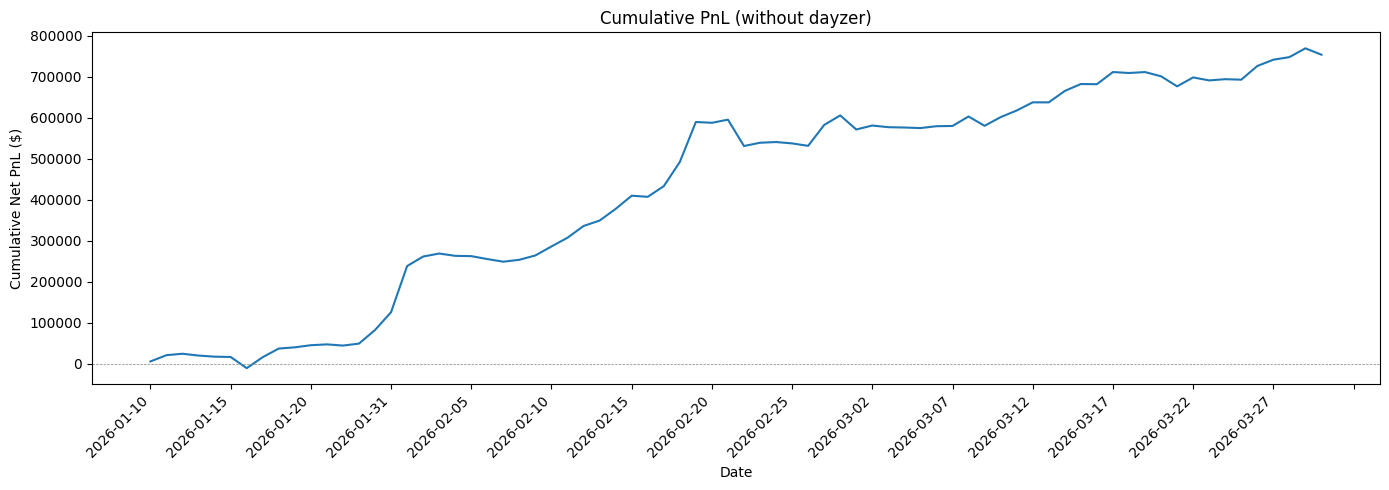

Total PnL:          $754,229.55
Max Daily Loss:     $-64,395.41
Profit-to-Loss:     3.88
Profit Days Total:  $1,015,898.64
Loss Days Total:    $-261,669.09
Win Rate:           63.5%


In [ ]:
import matplotlib.pyplot as plt

date_list = pd.date_range(start='2026-01-23', end='2026-01-28').strftime('%Y-%m-%d').tolist()
dayzer_wt_re = dayzer_wt_re[~dayzer_wt_re['dt'].isin(date_list)]

# Daily PnL
daily_pnl = dayzer_wt_re.groupby('dt')['net_pnl'].sum().reset_index()
daily_pnl.columns = ['dt', 'daily_pnl']
daily_pnl['cumulative_pnl'] = daily_pnl['daily_pnl'].cumsum()

# Cumulative PnL graph
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_pnl['dt'], daily_pnl['cumulative_pnl'], linewidth=1.5)
ax.set_title('Cumulative PnL (without dayzer)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Net PnL ($)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
ax.xaxis.set_major_locator(plt.MaxNLocator(20))
plt.tight_layout()
plt.show()

# Summary stats
total_pnl = daily_pnl['daily_pnl'].sum()
profit_days = daily_pnl[daily_pnl['daily_pnl'] > 0]['daily_pnl'].sum()
loss_days = daily_pnl[daily_pnl['daily_pnl'] < 0]['daily_pnl'].sum()
max_loss = daily_pnl['daily_pnl'].min()
profit_to_loss = abs(profit_days / loss_days) if loss_days != 0 else float('inf')

print(f'Total PnL:          ${total_pnl:,.2f}')
print(f'Max Daily Loss:     ${max_loss:,.2f}')
print(f'Profit-to-Loss:     {profit_to_loss:.2f}')
print(f'Profit Days Total:  ${profit_days:,.2f}')
print(f'Loss Days Total:    ${loss_days:,.2f}')
print(f'Win Rate:           {(daily_pnl["daily_pnl"] > 0).mean():.1%}')

# Sanity Check with the SPPFinalBidBeforeAnyCut

In [ ]:
import sys
sys.path.append('/var/www/python/Prod/nighthawk/')
import pandas as pd
import numpy as np
from nighthawk.util import connections

# 1. Load production Darwin bids from odessa_Bid
conn = connections.get_sql_connection(database='odessa_Bid')
prod_bids = pd.read_sql("""
    SELECT dt, hr, node_num, segment, bid_mw, bid_price, incdec
    FROM SPPFinalBidsBeforeAnyCut
    WHERE strategy = 'Darwin' AND dt BETWEEN '2026-01-10' AND '2026-03-30'
""", conn)
prod_bids['dt'] = prod_bids['dt'].astype(str)
print(f'Production bids: {prod_bids.shape}')

# 2. Load your Darwin with-dayzer portfolio
my_bids = pd.read_csv('/var/www/python/Qingcheng/WFiles/darwin_port_with_dayzer.csv')
my_bids['dt'] = my_bids['dt'].astype(str)
print(f'My bids: {my_bids.shape}')

# 3. Daily comparison
prod_daily = prod_bids.groupby('dt').agg(
    prod_n_bids=('bid_mw', 'count'),
    prod_total_mw=('bid_mw', 'sum')).reset_index()
my_daily = my_bids.groupby('dt').agg(
    my_n_bids=('bid_mw', 'count'),
    my_total_mw=('bid_mw', 'sum')).reset_index()

compare = prod_daily.merge(my_daily, on='dt', how='outer').sort_values('dt')
compare['mw_diff'] = compare['my_total_mw'] - compare['prod_total_mw']
compare['mw_diff_pct'] = (compare['mw_diff'] / compare['prod_total_mw'] * 100).round(1)
print('\nDaily MW comparison (first 20 dates):')
display(compare.head(20))

# 4. Summary stats
print(f"\nProduction: {prod_daily['prod_total_mw'].sum():,.0f} total MW across {len(prod_daily)} dates")
print(f"My bids:    {my_daily['my_total_mw'].sum():,.0f} total MW across {len(my_daily)} dates")
print(f"Avg daily MW diff: {compare['mw_diff'].mean():,.0f}")
print(f"Avg daily MW diff %: {compare['mw_diff_pct'].mean():.1f}%")

# 5. Node-level overlap check for a sample date
sample_dt = compare['dt'].iloc[0]
prod_nodes = set(prod_bids[prod_bids['dt'] == sample_dt]['node_num'].unique())
my_nodes = set(my_bids[my_bids['dt'] == sample_dt]['node_num'].unique())
print(f"\nNode overlap for {sample_dt}:")
print(f"  Production nodes: {len(prod_nodes)}")
print(f"  My nodes: {len(my_nodes)}")
print(f"  Overlap: {len(prod_nodes & my_nodes)}")
print(f"  Only in prod: {len(prod_nodes - my_nodes)}")
print(f"  Only in mine: {len(my_nodes - prod_nodes)}")

# 3. Daily comparison
prod_daily_ndoe = prod_bids.groupby(['dt','node_num']).agg(
    prod_n_bids=('bid_mw', 'count'),
    prod_total_mw=('bid_mw', 'sum')).reset_index()
my_daily_node = my_bids.groupby(['dt','node_num']).agg(
    my_n_bids=('bid_mw', 'count'),
    my_total_mw=('bid_mw', 'sum')).reset_index()

compare_node = prod_daily_ndoe.merge(my_daily_node, on=['dt','node_num'], how='outer').sort_values('dt')
compare_node['mw_diff'] = abs(compare_node['my_total_mw'] - compare_node['prod_total_mw'])
compare_node['mw_diff_pct'] = (compare_node['mw_diff'] / compare_node['prod_total_mw'] * 100).round(1)
compare_node_final = compare_node.groupby(['dt'])['mw_diff'].sum()
print('\nDaily MW and Node comparison (first 20 dates):')
display(compare_node_final.head(20))

Production bids: (130192, 7)
My bids: (129642, 35)

Daily MW comparison (first 20 dates):


,dt,prod_n_bids,prod_total_mw,my_n_bids,my_total_mw,mw_diff,mw_diff_pct
0,2026-01-10,1806.0,8113.140,1676,7538.670,-574.470,-7.1
1,2026-01-11,1125.0,5060.520,1612,7242.390,2181.870,43.1
2,2026-01-12,1201.0,5387.940,1224,5296.050,-91.890,-1.7
3,2026-01-13,1691.0,7599.780,1665,7456.410,-143.370,-1.9
4,2026-01-14,2096.0,9429.480,1832,8239.590,-1189.890,-12.6
5,2026-01-15,1903.0,8560.170,1832,8243.100,-317.070,-3.7
6,2026-01-16,1575.0,8857.350,1500,8437.275,-420.075,-4.7
7,2026-01-17,911.0,4072.320,1234,5531.850,1459.530,35.8
8,2026-01-18,1156.0,5197.770,1036,4652.370,-545.400,-10.5
9,2026-01-19,1408.0,6331.230,1408,6333.750,2.520,0.0



Production: 576,137 total MW across 79 dates
My bids:    574,381 total MW across 80 dates
Avg daily MW diff: -123
Avg daily MW diff %: -1.1%

Node overlap for 2026-01-10:
  Production nodes: 61
  My nodes: 59
  Overlap: 58
  Only in prod: 3
  Only in mine: 1

Daily MW and Node comparison (first 20 dates):


dt
2026-01-10    1947.330
2026-01-11     405.540
2026-01-12    1621.260
2026-01-13    2107.350
2026-01-14    1686.330
2026-01-15    1173.330
2026-01-16    1818.900
2026-01-17    1169.460
2026-01-18    1185.480
2026-01-19    1197.360
2026-01-20    1810.890
2026-01-21    1188.090
2026-01-22    1532.304
2026-01-23    1596.060
2026-01-24     247.392
2026-01-25     755.784
2026-01-26    1516.320
2026-01-27    1559.088
2026-01-28    1314.864
2026-01-29    2674.260
Name: mw_diff, dtype: float64

In [9]:
import sys
sys.path.append('/var/www/python/Prod/nighthawk/')
import pandas as pd
import numpy as np
from nighthawk.util import connections

# 1. Load production Fourier bids from odessa_Bid
conn = connections.get_sql_connection(database='odessa_Bid')
prod_bids = pd.read_sql("""
    SELECT dt, hr, node_num, segment, bid_mw, bid_price, incdec
    FROM SPPFinalBidsBeforeAnyCut
    WHERE strategy = 'Fourier' AND dt BETWEEN '2026-01-10' AND '2026-03-30'
""", conn)
prod_bids['dt'] = prod_bids['dt'].astype(str)
print(f'Production bids: {prod_bids.shape}')

# 2. Load your Fourier with-dayzer portfolio
my_bids = pd.read_csv('/var/www/python/Qingcheng/WFiles/fourier_port_with_dayzer.csv')
my_bids['dt'] = my_bids['dt'].astype(str)
print(f'My bids: {my_bids.shape}')

# 3. Daily comparison
prod_daily = prod_bids.groupby('dt').agg(
    prod_n_bids=('bid_mw', 'count'),
    prod_total_mw=('bid_mw', 'sum')).reset_index()
my_daily = my_bids.groupby('dt').agg(
    my_n_bids=('bid_mw', 'count'),
    my_total_mw=('bid_mw', 'sum')).reset_index()

compare = prod_daily.merge(my_daily, on='dt', how='outer').sort_values('dt')
compare['mw_diff'] = compare['my_total_mw'] - compare['prod_total_mw']
compare['mw_diff_pct'] = (compare['mw_diff'] / compare['prod_total_mw'] * 100).round(1)
print('\nDaily MW comparison (first 20 dates):')
display(compare.head(20))

# 4. Summary stats
print(f"\nProduction: {prod_daily['prod_total_mw'].sum():,.0f} total MW across {len(prod_daily)} dates")
print(f"My bids:    {my_daily['my_total_mw'].sum():,.0f} total MW across {len(my_daily)} dates")
print(f"Avg daily MW diff: {compare['mw_diff'].mean():,.0f}")
print(f"Avg daily MW diff %: {compare['mw_diff_pct'].mean():.1f}%")

# 5. Node-level overlap check for a sample date
sample_dt = compare['dt'].iloc[0]
prod_nodes = set(prod_bids[prod_bids['dt'] == sample_dt]['node_num'].unique())
my_nodes = set(my_bids[my_bids['dt'] == sample_dt]['node_num'].unique())
print(f"\nNode overlap for {sample_dt}:")
print(f"  Production nodes: {len(prod_nodes)}")
print(f"  My nodes: {len(my_nodes)}")
print(f"  Overlap: {len(prod_nodes & my_nodes)}")
print(f"  Only in prod: {len(prod_nodes - my_nodes)}")
print(f"  Only in mine: {len(my_nodes - prod_nodes)}")

# 3. Daily comparison
prod_daily_ndoe = prod_bids.groupby(['dt','node_num']).agg(
    prod_n_bids=('bid_mw', 'count'),
    prod_total_mw=('bid_mw', 'sum')).reset_index()
my_daily_node = my_bids.groupby(['dt','node_num']).agg(
    my_n_bids=('bid_mw', 'count'),
    my_total_mw=('bid_mw', 'sum')).reset_index()

compare_node = prod_daily_ndoe.merge(my_daily_node, on=['dt','node_num'], how='outer').sort_values('dt')
compare_node['mw_diff'] = abs(compare_node['my_total_mw'] - compare_node['prod_total_mw'])
compare_node['mw_diff_pct'] = (compare_node['mw_diff'] / compare_node['prod_total_mw'] * 100).round(1)
compare_node_final = compare_node.groupby(['dt'])['mw_diff'].sum()
print('\nDaily MW and Node comparison (first 20 dates):')
display(compare_node_final.head(20))

Production bids: (173659, 7)
My bids: (174426, 35)

Daily MW comparison (first 20 dates):


,dt,prod_n_bids,prod_total_mw,my_n_bids,my_total_mw,mw_diff,mw_diff_pct
0,2026-01-10,2567.0,8332.805,2590,11644.92,3312.115,39.7
1,2026-01-11,2429.0,7880.080,2475,11124.81,3244.730,41.2
2,2026-01-12,2204.0,7153.900,2373,10658.79,3504.890,49.0
3,2026-01-13,2466.0,7997.340,2419,10868.04,2870.700,35.9
4,2026-01-14,2313.0,7500.675,2284,10260.81,2760.135,36.8
5,2026-01-15,2256.0,7329.400,2142,9625.77,2296.370,31.3
6,2026-01-16,2512.0,8155.095,2532,11372.40,3217.305,39.5
7,2026-01-17,2196.0,7123.090,2295,10300.05,3176.960,44.6
8,2026-01-18,2136.0,6867.442,2117,9513.36,2645.918,38.5
9,2026-01-19,2116.0,6858.865,1914,8602.29,1743.425,25.4



Production: 563,428 total MW across 79 dates
My bids:    783,750 total MW across 80 dates
Avg daily MW diff: 2,685
Avg daily MW diff %: 38.8%

Node overlap for 2026-01-10:
  Production nodes: 55
  My nodes: 55
  Overlap: 52
  Only in prod: 3
  Only in mine: 3

Daily MW and Node comparison (first 20 dates):


dt
2026-01-10    7476.445
2026-01-11    5820.010
2026-01-12    7103.665
2026-01-13    6374.740
2026-01-14    6440.765
2026-01-15    6506.180
2026-01-16    6486.615
2026-01-17    6475.370
2026-01-18    5039.468
2026-01-19    5553.555
2026-01-20    5860.680
2026-01-21    5150.050
2026-01-22    6995.635
2026-01-23    4847.755
2026-01-24    2006.040
2026-01-25    1827.670
2026-01-26    1671.205
2026-01-27    2273.035
2026-01-28    2452.945
2026-01-29    3194.325
Name: mw_diff, dtype: float64